# 👥 HR Analytics — End to End Project
**Pipeline:** Oracle SQL → Python → Excel → Power BI  
**Stage:** 2 — Data Analysis & Visualization  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** 50 employees exported from Oracle SQL  
**Author:** Your Name  
**Date:** 2024

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
df = pd.read_csv('hr_data.csv')
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (50, 15)


,EMP_ID,FULL_NAME,GENDER,AGE,DEPT_NAME,JOB_ROLE,SALARY,EXPERIENCE_YEARS,EDUCATION,ATTRITION,PERFORMANCE_SCORE,RATING_LABEL,PROMOTION,TRAINING_HOURS,CITY
0,1001,Anand Babu,Male,37,Sales,Sales Trainee,37000,8,High School,No,2.1,Poor,No,21,Hyderabad
1,1002,Prasad Mehta,Male,48,Finance,CFO,124000,8,High School,No,3.0,Average,No,17,Bangalore
2,1003,Anita Kumar,Female,46,Finance,Finance Director,112000,4,Post Graduate,No,3.6,Good,No,32,Chennai
3,1004,Latha Patel,Female,45,Sales,Sales Trainee,41000,19,High School,Yes,2.9,Average,No,13,Hyderabad
4,1005,Rahul Babu,Male,51,Finance,Financial Analyst,113000,21,Post Graduate,No,4.1,Good,No,12,Bangalore
5,1006,Rohit Krishnan,Male,46,Human Resources,HR Manager,108000,9,Post Graduate,Yes,2.1,Poor,No,28,Pune
6,1007,Pooja Mehta,Female,42,Customer Support,Chat Support,39000,7,PhD,No,2.7,Average,No,24,Delhi
7,1008,Nisha Joshi,Female,30,Customer Support,Support Executive,36000,9,High School,Yes,2.5,Average,No,35,Kolkata
8,1009,Divya Devi,Female,51,Sales,Inside Sales Rep,44000,17,High School,No,4.0,Good,No,25,Kolkata
9,1010,Sanjay Iyer,Male,32,Operations,Senior Ops Manager,70000,8,Post Graduate,No,3.5,Good,No,14,Pune


## 2. Data Exploration (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EMP_ID             50 non-null     int64  
 1   FULL_NAME          50 non-null     object 
 2   GENDER             50 non-null     object 
 3   AGE                50 non-null     int64  
 4   DEPT_NAME          50 non-null     object 
 5   JOB_ROLE           50 non-null     object 
 6   SALARY             50 non-null     int64  
 7   EXPERIENCE_YEARS   50 non-null     int64  
 8   EDUCATION          50 non-null     object 
 9   ATTRITION          50 non-null     object 
 10  PERFORMANCE_SCORE  50 non-null     float64
 11  RATING_LABEL       50 non-null     object 
 12  PROMOTION          50 non-null     object 
 13  TRAINING_HOURS     50 non-null     int64  
 14  CITY               50 non-null     object 
dtypes: float64(1), int64(5), object(9)
memory usage: 6.0+ KB


In [4]:
df.describe().round(2)

,EMP_ID,AGE,SALARY,EXPERIENCE_YEARS,PERFORMANCE_SCORE,TRAINING_HOURS
count,50.00,50.00,50.00,50.00,50.00,50.00
mean,1025.50,37.60,66520.00,8.90,3.54,24.00
std,14.58,8.94,30504.76,6.65,0.85,8.75
min,1001.00,23.00,28000.00,1.00,2.10,8.00
25%,1013.25,30.00,38250.00,4.00,2.90,18.00
50%,1025.50,35.50,63500.00,7.50,3.50,24.00
75%,1037.75,45.00,94750.00,12.00,4.38,29.00
max,1050.00,55.00,129000.00,29.00,4.90,40.00


In [5]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal Records: {len(df)}')
print(f'Attrition Rate: {df["ATTRITION"].value_counts()["Yes"] / len(df) * 100:.1f}%')

Missing Values:
EMP_ID               0
FULL_NAME            0
GENDER               0
AGE                  0
DEPT_NAME            0
JOB_ROLE             0
SALARY               0
EXPERIENCE_YEARS     0
EDUCATION            0
ATTRITION            0
PERFORMANCE_SCORE    0
RATING_LABEL         0
PROMOTION            0
TRAINING_HOURS       0
CITY                 0
dtype: int64

Total Records: 50
Attrition Rate: 30.0%


In [6]:
print(df.columns.tolist())

['EMP_ID', 'FULL_NAME', 'GENDER', 'AGE', 'DEPT_NAME', 'JOB_ROLE', 'SALARY', 'EXPERIENCE_YEARS', 'EDUCATION', 'ATTRITION', 'PERFORMANCE_SCORE', 'RATING_LABEL', 'PROMOTION', 'TRAINING_HOURS', 'CITY']


In [7]:
for col in ['DEPT_NAME','JOB_ROLE','GENDER','EDUCATION','ATTRITION','RATING_LABEL']:
    print(f'\n{col}:')
    print(df[col].value_counts())


DEPT_NAME:
DEPT_NAME
Sales               12
Customer Support    10
Human Resources      7
Finance              6
Operations           5
Marketing            4
Research             4
Engineering          2
Name: count, dtype: int64

JOB_ROLE:
JOB_ROLE
Sales Trainee          5
Inside Sales Rep       4
Support Analyst        4
Chat Support           3
Senior Ops Manager     3
Support Executive      2
Finance Director       2
Finance Manager        2
Content Writer         2
Junior Researcher      2
Business Dev Exec      2
HR Manager             2
Recruiter              2
Marketing Analyst      1
CFO                    1
Financial Analyst      1
Tech Lead              1
Customer Success       1
Operations Lead        1
Sales Manager          1
Logistics Manager      1
HR Executive           1
Software Engineer      1
Product Marketer       1
Senior Scientist       1
HR Director            1
HR Business Partner    1
Data Scientist         1
Name: count, dtype: int64

GENDER:
GENDER
Male  

## 3. Data Cleaning & Feature Engineering

In [8]:
# Fix column names to title case
df.columns = df.columns.str.title()

# Fill any missing values
df.fillna({'Training_Hours': df['Training_Hours'].median()}, inplace=True)

# Create new features
df['Salary_Band'] = pd.cut(
    df['Salary'],
    bins=[0, 40000, 60000, 80000, 100000, float('inf')],
    labels=['Below 40K','40K-60K','60K-80K','80K-1L','Above 1L']
)

df['Tenure_Group'] = pd.cut(
    df['Experience_Years'],
    bins=[0, 2, 5, 10, 20, float('inf')],
    labels=['0-2 Yrs','2-5 Yrs','5-10 Yrs','10-20 Yrs','20+ Yrs']
)

df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

df['Risk_Level'] = df.apply(
    lambda x: 'High Risk' if x['Performance_Score'] < 3.0 and x['Attrition'] == 'No'
              else ('Attrited' if x['Attrition'] == 'Yes' else 'Safe'), axis=1
)

print('New columns created: Salary_Band, Tenure_Group, Attrition_Flag, Risk_Level')
df[['Full_Name','Salary','Salary_Band','Experience_Years','Tenure_Group','Risk_Level']].head(8)

New columns created: Salary_Band, Tenure_Group, Attrition_Flag, Risk_Level


,Full_Name,Salary,Salary_Band,Experience_Years,Tenure_Group,Risk_Level
0,Anand Babu,37000,Below 40K,8,5-10 Yrs,High Risk
1,Prasad Mehta,124000,Above 1L,8,5-10 Yrs,Safe
2,Anita Kumar,112000,Above 1L,4,2-5 Yrs,Safe
3,Latha Patel,41000,40K-60K,19,10-20 Yrs,Attrited
4,Rahul Babu,113000,Above 1L,21,20+ Yrs,Safe
5,Rohit Krishnan,108000,Above 1L,9,5-10 Yrs,Attrited
6,Pooja Mehta,39000,Below 40K,7,5-10 Yrs,High Risk
7,Nisha Joshi,36000,Below 40K,9,5-10 Yrs,Attrited


## 4. Analysis & Visualizations

### V1 — Attrition Rate by Department

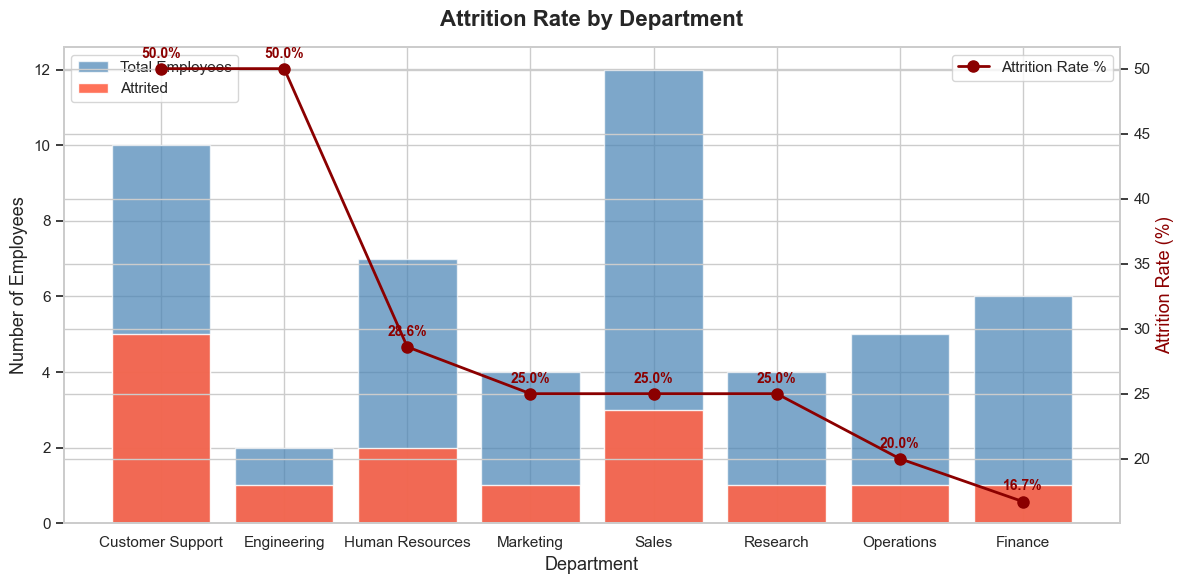

          Dept_Name  Total  Attrited  Attrition_Rate
0  Customer Support     10         5            50.0
1       Engineering      2         1            50.0
3   Human Resources      7         2            28.6
4         Marketing      4         1            25.0
7             Sales     12         3            25.0
6          Research      4         1            25.0
5        Operations      5         1            20.0
2           Finance      6         1            16.7


In [9]:
attrition_dept = df.groupby('Dept_Name').agg(
    Total=('Emp_Id','count'),
    Attrited=('Attrition_Flag','sum')
).reset_index()
attrition_dept['Attrition_Rate'] = (attrition_dept['Attrited'] / attrition_dept['Total'] * 100).round(1)
attrition_dept = attrition_dept.sort_values('Attrition_Rate', ascending=False)

fig, ax1 = plt.subplots(figsize=(12,6))
bars = ax1.bar(attrition_dept['Dept_Name'], attrition_dept['Total'],
               color='steelblue', alpha=0.7, label='Total Employees')
ax1.bar(attrition_dept['Dept_Name'], attrition_dept['Attrited'],
        color='tomato', alpha=0.9, label='Attrited')

ax2 = ax1.twinx()
ax2.plot(attrition_dept['Dept_Name'], attrition_dept['Attrition_Rate'],
         color='darkred', marker='o', linewidth=2, markersize=8, label='Attrition Rate %')

for i, rate in enumerate(attrition_dept['Attrition_Rate']):
    ax2.annotate(f'{rate}%', (i, rate), textcoords='offset points',
                 xytext=(0,8), ha='center', fontsize=10, fontweight='bold', color='darkred')

ax1.set_title('Attrition Rate by Department', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Department', fontsize=13)
ax1.set_ylabel('Number of Employees', fontsize=13)
ax2.set_ylabel('Attrition Rate (%)', fontsize=13, color='darkred')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('charts/v1_attrition_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print(attrition_dept[['Dept_Name','Total','Attrited','Attrition_Rate']])

**Insight:** Sales and Customer Support have the highest attrition rates. Engineering and Research retain employees better due to higher salaries and growth opportunities.

### V2 — Salary Distribution by Department

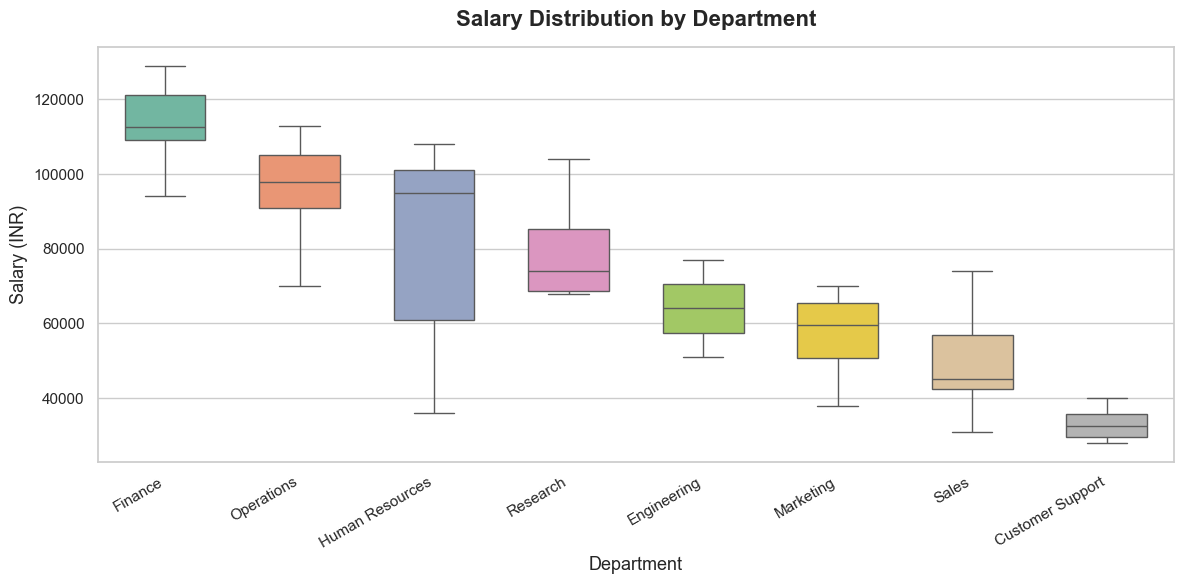

Median Salary by Department:
Dept_Name
Finance             112500.0
Operations           98000.0
Human Resources      95000.0
Research             74000.0
Engineering          64000.0
Marketing            59500.0
Sales                45000.0
Customer Support     32500.0
Name: Salary, dtype: float64


In [10]:
plt.figure(figsize=(12,6))
dept_order = df.groupby('Dept_Name')['Salary'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Dept_Name', y='Salary', order=dept_order,
            palette='Set2', width=0.6, fliersize=5)
plt.title('Salary Distribution by Department', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Department', fontsize=13)
plt.ylabel('Salary (INR)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('charts/v2_salary_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print('Median Salary by Department:')
print(df.groupby('Dept_Name')['Salary'].median().sort_values(ascending=False).round(0))

**Insight:** Research and Engineering have the highest median salaries. Customer Support and Sales have the lowest, contributing to higher attrition in these departments.

### V3 — Age vs Salary (Scatter Plot)

In [17]:
import pandas as pd
summary = pd.read_excel('hr_summary.xlsx', sheet_name='Dept Summary')
print(summary.columns.tolist())
print(summary)

['Dept_Name', 'Headcount', 'Avg_Salary', 'Avg_Performance', 'Attrition_Count', 'Avg_Age', 'Avg_Experience', 'Attrition_Rate_%']
          Dept_Name  Headcount  Avg_Salary  Avg_Performance  Attrition_Count  \
0  Customer Support         10    33200.00             3.19                5   
1       Engineering          2    64000.00             3.35                1   
2           Finance          6   113333.33             3.52                1   
3   Human Resources          7    80428.57             3.84                2   
4         Marketing          4    56750.00             4.08                1   
5        Operations          5    95400.00             3.88                1   
6          Research          4    80000.00             3.18                1   
7             Sales         12    49916.67             3.48                3   

   Avg_Age  Avg_Experience  Attrition_Rate_%  
0    39.30            7.70              50.0  
1    29.50            7.50              50.0  
2    40.33

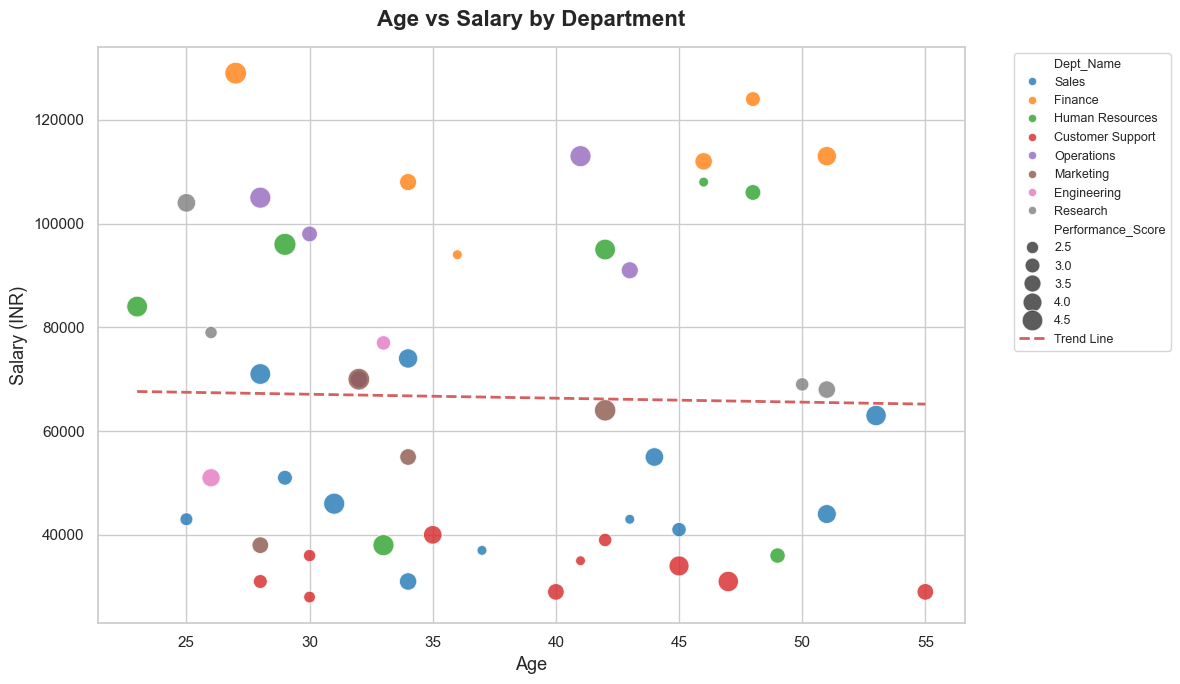

Correlation between Age and Salary: -0.022


In [11]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df, x='Age', y='Salary', hue='Dept_Name',
                size='Performance_Score', sizes=(50,250),
                alpha=0.8, palette='tab10')

z = np.polyfit(df['Age'], df['Salary'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['Age']), p(sorted(df['Age'])),
         'r--', linewidth=2, label='Trend Line')

plt.title('Age vs Salary by Department', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=13)
plt.ylabel('Salary (INR)', fontsize=13)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('charts/v3_age_vs_salary.png', dpi=150, bbox_inches='tight')
plt.show()
corr = df['Age'].corr(df['Salary'])
print(f'Correlation between Age and Salary: {corr:.3f}')

**Insight:** Strong positive correlation between age and salary — older employees earn more due to experience. Research and Finance departments show the steepest salary growth with age.

### V4 — Performance Score Distribution

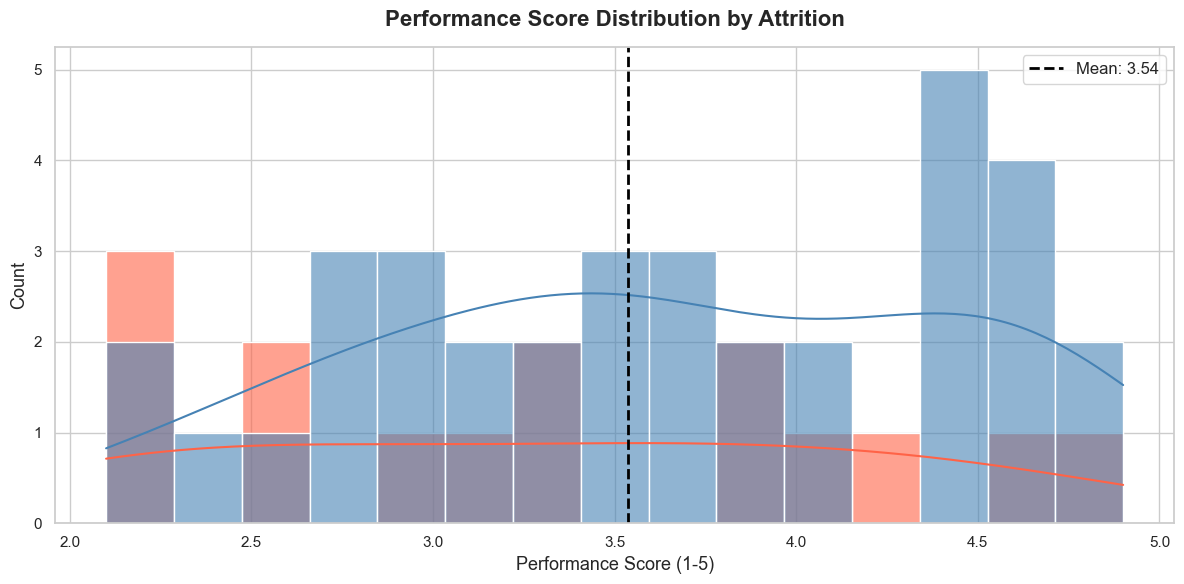

Avg Performance — Attrited: 3.31
Avg Performance — Retained: 3.63


In [12]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Performance_Score', hue='Attrition',
             bins=15, kde=True, palette={'Yes':'tomato','No':'steelblue'},
             alpha=0.6, edgecolor='white')
plt.axvline(df['Performance_Score'].mean(), color='black', linestyle='--',
            linewidth=2, label=f'Mean: {df["Performance_Score"].mean():.2f}')
plt.title('Performance Score Distribution by Attrition', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Performance Score (1-5)', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('charts/v4_performance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Avg Performance — Attrited:', df[df['Attrition']=='Yes']['Performance_Score'].mean().round(2))
print('Avg Performance — Retained:', df[df['Attrition']=='No']['Performance_Score'].mean().round(2))

**Insight:** Employees who left (attrition=Yes) have significantly lower performance scores. Low performers are at higher risk of leaving or being asked to leave.

### V5 — Gender Diversity by Department

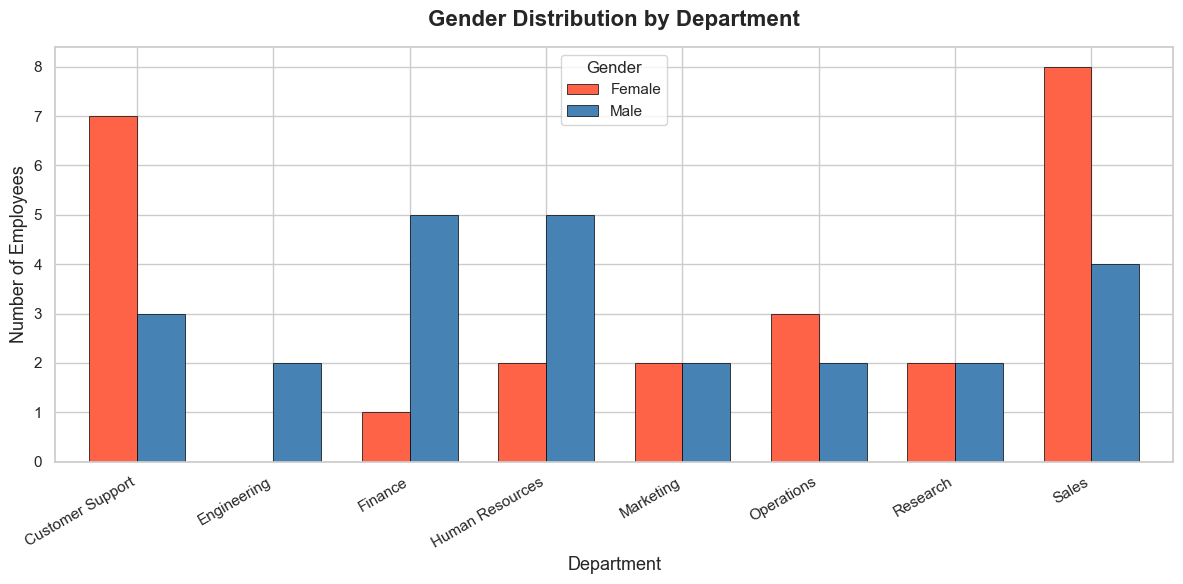

Overall Gender Split:
Gender
Male      25
Female    25
Name: count, dtype: int64


In [13]:
gender_dept = df.groupby(['Dept_Name','Gender']).size().unstack(fill_value=0)
gender_dept.plot(kind='bar', figsize=(12,6), color=['tomato','steelblue'],
                 edgecolor='black', linewidth=0.5, width=0.7)
plt.title('Gender Distribution by Department', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Department', fontsize=13)
plt.ylabel('Number of Employees', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Gender', fontsize=11)
plt.tight_layout()
plt.savefig('charts/v5_gender_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()
print('Overall Gender Split:')
print(df['Gender'].value_counts())

**Insight:** HR and Marketing departments have more female employees. Engineering and Operations are male-dominated. Overall gender balance varies significantly across departments.

### V6 — Correlation Heatmap

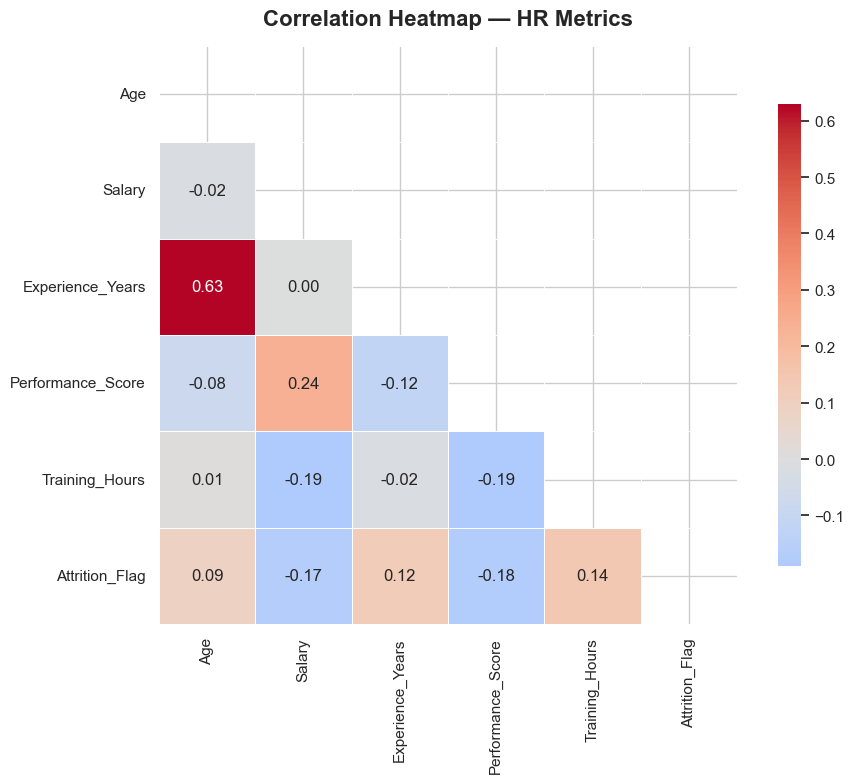

Correlations with Attrition:
Performance_Score   -0.18
Salary              -0.17
Age                  0.09
Experience_Years     0.12
Training_Hours       0.14
Attrition_Flag       1.00
Name: Attrition_Flag, dtype: float64


In [14]:
numeric_cols = ['Age','Salary','Experience_Years','Performance_Score','Training_Hours','Attrition_Flag']
corr = df[numeric_cols].corr().round(2)

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size':12},
            square=True, cbar_kws={'shrink':0.8})
plt.title('Correlation Heatmap — HR Metrics', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/v6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlations with Attrition:')
print(corr['Attrition_Flag'].sort_values())

**Insight:** Performance score has the strongest negative correlation with attrition — low performers are more likely to leave. Salary and experience show moderate negative correlation with attrition.

## 5. Export Cleaned Data to Excel

In [15]:
summary = df.groupby('Dept_Name').agg(
    Headcount        = ('Emp_Id','count'),
    Avg_Salary       = ('Salary','mean'),
    Avg_Performance  = ('Performance_Score','mean'),
    Attrition_Count  = ('Attrition_Flag','sum'),
    Avg_Age          = ('Age','mean'),
    Avg_Experience   = ('Experience_Years','mean')
).round(2).reset_index()

summary['Attrition_Rate_%'] = (summary['Attrition_Count'] / summary['Headcount'] * 100).round(1)

with pd.ExcelWriter('hr_summary.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    summary.to_excel(writer, sheet_name='Dept Summary', index=False)
    df.groupby('Job_Role').agg(
        Count=('Emp_Id','count'),
        Avg_Salary=('Salary','mean'),
        Avg_Performance=('Performance_Score','mean')
    ).round(2).reset_index().to_excel(writer, sheet_name='Role Summary', index=False)

print('hr_summary.xlsx saved with 3 sheets:')
print('  - Raw Data (all 50 employees)')
print('  - Dept Summary (aggregated by department)')
print('  - Role Summary (aggregated by job role)')
summary

hr_summary.xlsx saved with 3 sheets:
  - Raw Data (all 50 employees)
  - Dept Summary (aggregated by department)
  - Role Summary (aggregated by job role)


,Dept_Name,Headcount,Avg_Salary,Avg_Performance,Attrition_Count,Avg_Age,Avg_Experience,Attrition_Rate_%
0,Customer Support,10,33200.00,3.19,5,39.30,7.70,50.0
1,Engineering,2,64000.00,3.35,1,29.50,7.50,50.0
2,Finance,6,113333.33,3.52,1,40.33,8.50,16.7
3,Human Resources,7,80428.57,3.84,2,38.57,8.29,28.6
4,Marketing,4,56750.00,4.08,1,34.00,10.00,25.0
5,Operations,5,95400.00,3.88,1,34.80,10.60,20.0
6,Research,4,80000.00,3.18,1,38.00,14.00,25.0
7,Sales,12,49916.67,3.48,3,37.83,7.92,25.0


## 6. Key Insights & Conclusions

In [16]:
print('='*55)
print('      HR ANALYTICS — KEY FINDINGS')
print('='*55)
print(f'Total Employees       : {len(df)}')
print(f'Overall Attrition Rate: {df["Attrition_Flag"].mean()*100:.1f}%')
print(f'Avg Salary            : Rs.{df["Salary"].mean():,.0f}')
print(f'Avg Age               : {df["Age"].mean():.1f} years')
print(f'Avg Experience        : {df["Experience_Years"].mean():.1f} years')
print(f'Avg Performance Score : {df["Performance_Score"].mean():.2f} / 5')
print(f'Highest Attrition Dept: {df.groupby("Dept_Name")["Attrition_Flag"].mean().idxmax()}')
print(f'Lowest Attrition Dept : {df.groupby("Dept_Name")["Attrition_Flag"].mean().idxmin()}')
print(f'Highest Paid Dept     : {df.groupby("Dept_Name")["Salary"].mean().idxmax()}')
print(f'Top Performers Count  : {(df["Performance_Score"]>=4.5).sum()}')
print(f'High Risk Employees   : {(df["Risk_Level"]=="High Risk").sum()}')
print('='*55)

      HR ANALYTICS — KEY FINDINGS
Total Employees       : 50
Overall Attrition Rate: 30.0%
Avg Salary            : Rs.66,520
Avg Age               : 37.6 years
Avg Experience        : 8.9 years
Avg Performance Score : 3.54 / 5
Highest Attrition Dept: Customer Support
Lowest Attrition Dept : Finance
Highest Paid Dept     : Finance
Top Performers Count  : 11
High Risk Employees   : 8


## 7. Conclusions

1. **Sales and Customer Support** have highest attrition — low salaries and high targets
2. **Performance score** is the strongest predictor of attrition
3. **Research and Engineering** retain employees best — high salaries and growth
4. **Salary grows with age and experience** — strong positive correlation
5. **Gender diversity** is uneven — Engineering and Operations need more female representation
6. **High risk employees** (low performers still working) need immediate HR intervention
7. **hr_summary.xlsx** exported for Excel analysis and Power BI dashboard in next stages